# Creating Balanced Multi-Source Test Set

This notebook constructs the final evaluation dataset by merging:
- Real-world Ukrainian social media comments (manually labeled)
- Translated Jigsaw Toxic Comment samples selected to address underrepresented toxicity categories

This ensures balanced representation across all six toxicity categories: `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, and `identity_hate`.

## Importing Dependencies

In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd

from toxicity_detector.utils.plotting import plot_category_distribution
from toxicity_detector.config.paths import JIGSAW_PROCESSED, UKR_INTERIM
from toxicity_detector.config.labels import LABELS_EN

pd.set_option("display.max_colwidth", None)

## Loading Data

In [2]:
test_df = pd.read_csv(UKR_INTERIM["test"])  
jigsaw_test_df = pd.read_csv(JIGSAW_PROCESSED["test_uk"])

## Quick Exploration

In [ ]:

# Aligning dataframes
temp_df = jigsaw_test_df.drop(columns=[
 'label_count',
 'comment_length',
 'comment_text',
 'male',
 'female',
 'homosexual_gay_or_lesbian',
 'christian',
 'jewish',
 'muslim',
 'black',
 'white',
 'psychiatric_or_mental_illness',
 'category_count'])

temp_df.rename(columns={
    "translated": "comment"
}, inplace=True)

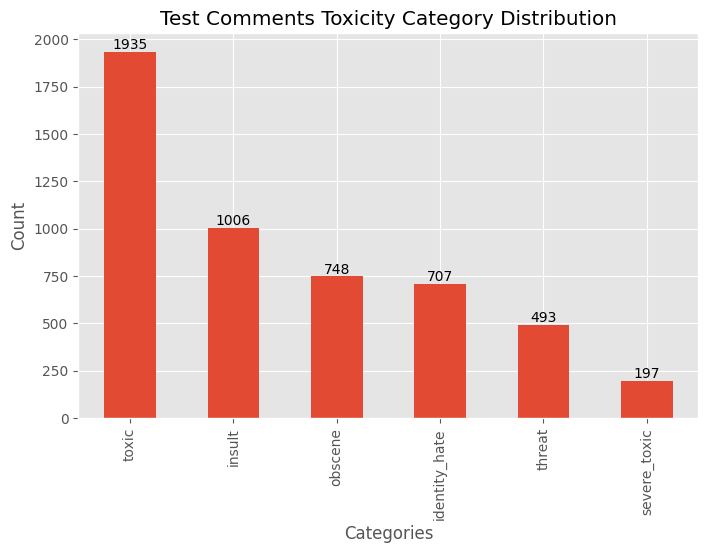

In [4]:
plot_category_distribution(temp_df, LABELS_EN, title="Test Comments Toxicity Category Distribution")

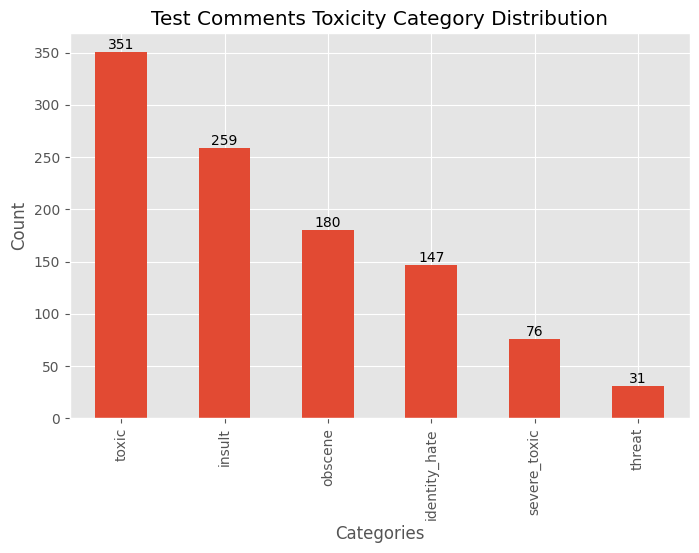

In [5]:
plot_category_distribution(test_df, LABELS_EN, title="Test Comments Toxicity Category Distribution")

## Combining Native and Translated Test Data

In [6]:
temp_df["keep"] = 0

In [7]:
def select_n_comments(df: pd.DataFrame, n: int, by: str = "toxic", col: str = "keep", value: int = 1):        
    amount = df[df[by] == value].shape[0]
    
    if amount < n:
        n = amount
        
    temp = df.loc[df[by] == value, col][:n]
    df.loc[temp.index, col] = 1

In [8]:
# Selecting toxic comments
select_n_comments(temp_df, 50, "insult")
select_n_comments(temp_df, 100, "obscene")
select_n_comments(temp_df, 100, "identity_hate")
select_n_comments(temp_df, 50, "severe_toxic")
select_n_comments(temp_df, 120, "threat")
select_n_comments(temp_df, 200, "toxic", value=0)
    
new_df = temp_df[temp_df["keep"] == 1]
new_df.shape

(511, 10)

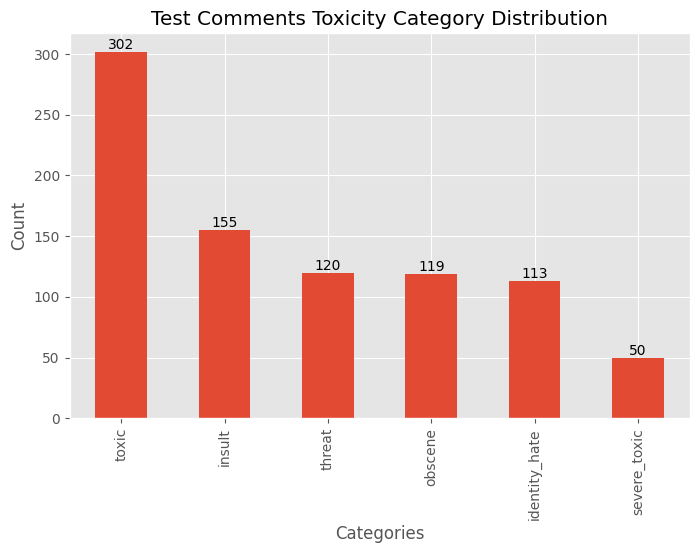

In [9]:
plot_category_distribution(new_df, LABELS_EN, title="Test Comments Toxicity Category Distribution")

In [10]:
df = pd.concat([test_df, new_df], axis=0)
df.shape

(1308, 10)

In [20]:
df.columns

Index(['id', 'comment', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate', 'comment_text', 'keep'],
      dtype='object')

In [11]:
df[df["toxic"] == 0].shape

(655, 10)

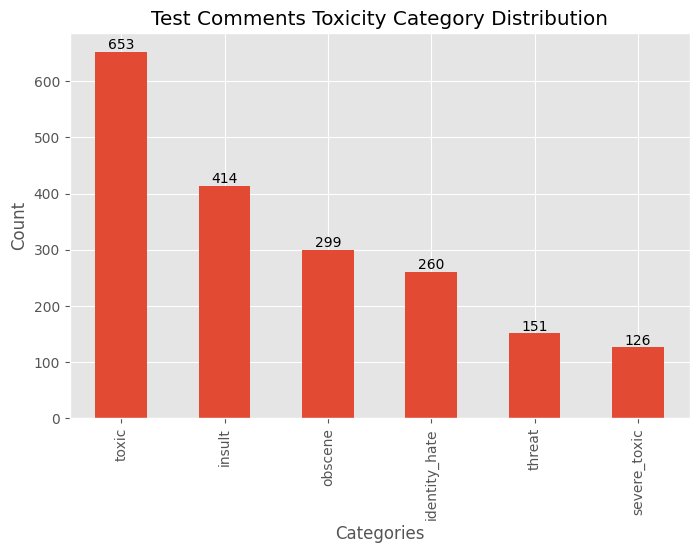

In [12]:
plot_category_distribution(df, LABELS_EN, title="Test Comments Toxicity Category Distribution")

## Test Set Construction & Export

In [14]:
temp_df = temp_df[temp_df["keep"] == 0]
temp_df.shape

(5488, 10)

In [18]:
jigsaw_test_df = jigsaw_test_df[jigsaw_test_df["id"].isin(temp_df["id"])]
jigsaw_test_df.shape

(5488, 21)

In [ ]:
df.drop(columns=["keep"], inplace=True)

In [ ]:
df.to_csv(UKR_INTERIM["test"], index=False)
jigsaw_test_df.to_csv(JIGSAW_PROCESSED["test_uk"], index=False)